In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

# List what is inside your Drive
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Figo_SYBSC_meme1.jpg', 'IMG_20211011_130912.jpg', '3059 FIGO FERNANDES Xi science A.jpg', 'certificate-1.pdf', '3059 Figo Fernandes xi science (1).pdf', '3059 Figo Fernandes xi science.pdf', 'Planning Poker _ Story Point Estimation in Agile _ Agile Estimation Techniques(480P).mp4', '20220728_142900.jpg', '4220.docx', 'Audio from FigoMarcus😶\u200d🌫️', 'figo_cs', '2302338_cs', '2302338_new', 'aman and figo sec assigment.pptx', 'figo_marcus_cs', '2302338_assignment', 'figo_sec', 'IMG-20231014-WA0003.jpg', 'IMG-20231014-WA0000.jpg', 'fake_Ejournal_2302338', 'figo.html', 'nss.jpg', 'nss1.jpg', 'figotable.html', 'figomenu.html', 'login.html', 'nss3.jpg', 'enrollment.html', '2302338_html', 'typo.html', 'hw.html', 'hw2.html', 'assignment.html', 'login1.html', 'login.php', 'purple-fluid-background_53876-99561.jpg', 'purple-fluid.jpg', 'blue.jpg', 'Background Design Images _ Free Photos, PNG Stickers, Wallpapers & Backgrounds - rawpixel.jpg', 'figo.bmpr', '2302338_Figo.bmpr'

In [6]:
# Change the name below if your folder has a different name
base_path = "/content/drive/MyDrive/Msc AI/Neural Networks/Garbage classification"

print("Contents of the folder:")
print(os.listdir(base_path))

Contents of the folder:
['paper', 'metal', 'glass', 'trash', 'cardboard', 'plastic']


In [8]:
data_dir = "/content/drive/MyDrive/Msc AI/Neural Networks/Garbage classification"

In [9]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print("\nTotal images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class to index:", full_dataset.class_to_idx)

# Split 80% train, 20% validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("\nTraining images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Using device: cuda

Total images: 2527
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Class to index: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Training images: 2021
Validation images: 506


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class WasteClassifier(nn.Module):
    def __init__(self, num_classes=6):
        super(WasteClassifier, self).__init__()

        # Convolutional layers (these extract features from images)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)   # reduces height & width by half
        self.relu = nn.ReLU()

        # After 3 pooling layers: 128 → 64 → 32 → 16
        # So final feature map size = 64 channels × 16 × 16
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.3)   # helps prevent overfitting

    def forward(self, x):
        # Forward Propagation
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)          # Flatten the feature maps
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                    # Final output (raw scores for 6 classes)
        return x

# Create the model and move it to GPU
model = WasteClassifier(num_classes=6).to(device)
print(model)

WasteClassifier(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()               # Loss function for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer ready.")

Loss function and optimizer ready.


In [12]:
num_epochs = 12
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # ---------- Training ----------
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 2. Backward pass + Optimize
        optimizer.zero_grad()      # clear old gradients
        loss.backward()            # calculate gradients (backpropagation)
        optimizer.step()           # update the weights

        running_loss += loss.item()

    # ---------- Validation ----------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    val_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  |  Loss: {epoch_loss:.4f}  |  Val Accuracy: {epoch_acc:.2f}%")

print("\nTraining finished!")

Epoch [1/12]  |  Loss: 1.4536  |  Val Accuracy: 57.31%
Epoch [2/12]  |  Loss: 1.1664  |  Val Accuracy: 63.64%
Epoch [3/12]  |  Loss: 1.0019  |  Val Accuracy: 65.22%
Epoch [4/12]  |  Loss: 0.8839  |  Val Accuracy: 65.42%
Epoch [5/12]  |  Loss: 0.7804  |  Val Accuracy: 70.16%
Epoch [6/12]  |  Loss: 0.6803  |  Val Accuracy: 68.77%
Epoch [7/12]  |  Loss: 0.5902  |  Val Accuracy: 70.16%
Epoch [8/12]  |  Loss: 0.5257  |  Val Accuracy: 72.33%
Epoch [9/12]  |  Loss: 0.4288  |  Val Accuracy: 71.94%
Epoch [10/12]  |  Loss: 0.3259  |  Val Accuracy: 70.16%
Epoch [11/12]  |  Loss: 0.2992  |  Val Accuracy: 73.72%
Epoch [12/12]  |  Loss: 0.2237  |  Val Accuracy: 72.13%

Training finished!


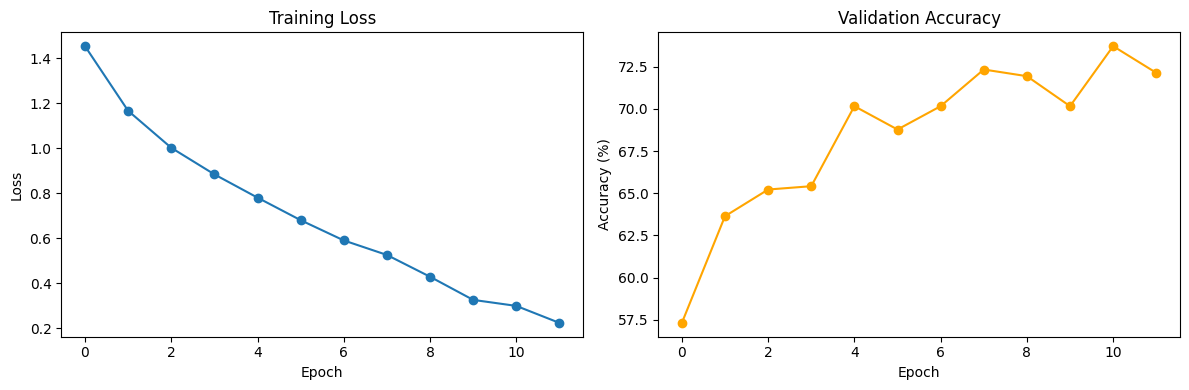

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, marker='o', color='orange')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

In [15]:
torch.save(model.state_dict(), "/content/drive/MyDrive/Msc AI/Neural Networks/waste_classifier.pth")
print("Model saved successfully to Google Drive!")

Model saved successfully to Google Drive!


In [16]:
# Only run this if the model is not already in memory
model = WasteClassifier(num_classes=6).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Msc AI/Neural Networks/waste_classifier.pth"))
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [17]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path, model, class_names):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)  # add batch dimension

    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    # Show the image and prediction
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class} ({confidence_score:.1f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence_score

In [19]:
# Make sure class_names is available
class_names = full_dataset.classes
print("Class names:", class_names)

Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


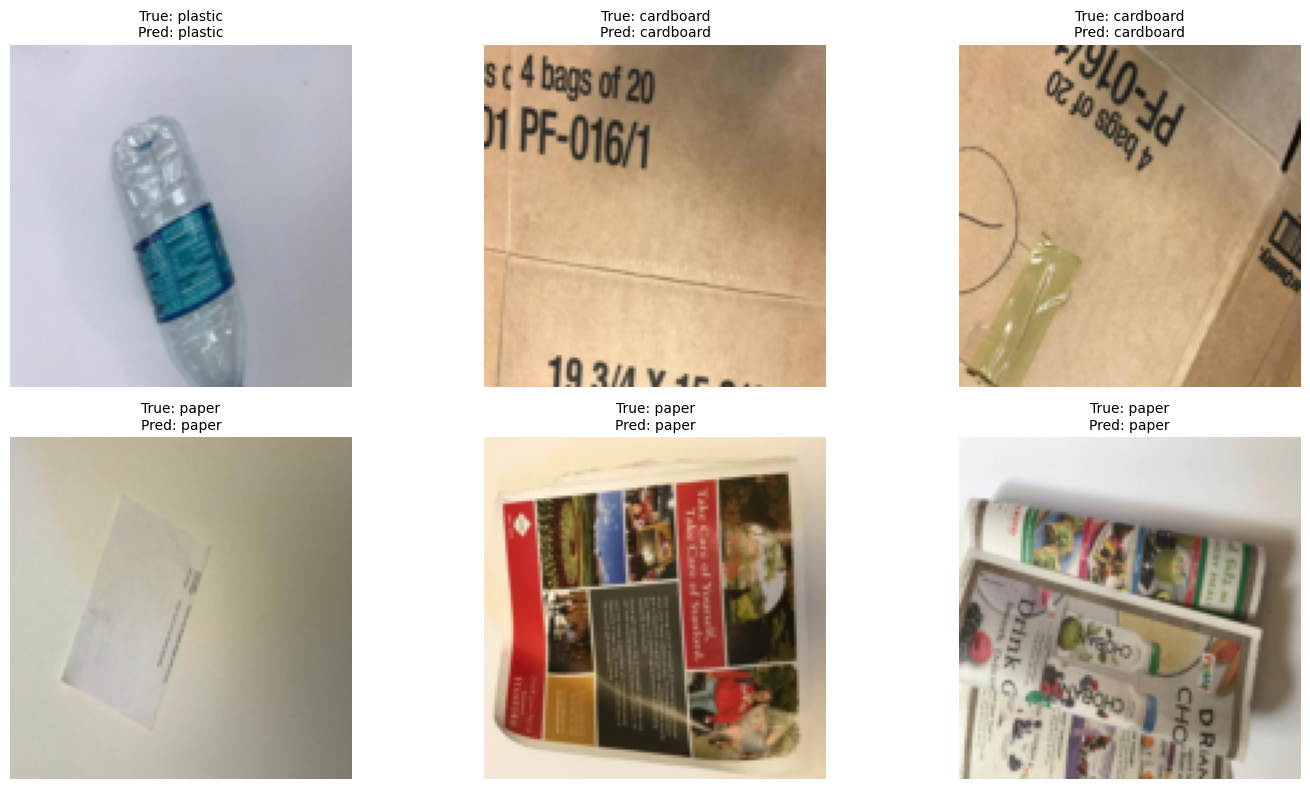

In [20]:
import random
import matplotlib.pyplot as plt

# Get 6 random images from validation set
indices = random.sample(range(len(val_dataset)), 6)

plt.figure(figsize=(15, 8))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    # Prepare image for model
    image_tensor = image.unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

    # Convert image for display
    img = image.cpu().permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5   # un-normalize
    img = img.clip(0, 1)

    true_class = class_names[label]
    pred_class = class_names[predicted.item()]

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"True: {true_class}\nPred: {pred_class}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()   # Upload a test image

# Replace the filename with the one you uploaded
predict_image("your_uploaded_image.jpg", model, class_names)

In [ ]:
# Calculate final accuracy cleanly
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_accuracy = 100 * correct / total
print(f"\nFinal Validation Accuracy: {final_accuracy:.2f}%")

In [22]:
from google.colab import files
from PIL import Image

# This will open a file selector
uploaded = files.upload()

Saving free-brown-glass-bottle-png-704081695121544zpdpcphifh.png to free-brown-glass-bottle-png-704081695121544zpdpcphifh.png


Uploaded file: free-brown-glass-bottle-png-704081695121544zpdpcphifh.png


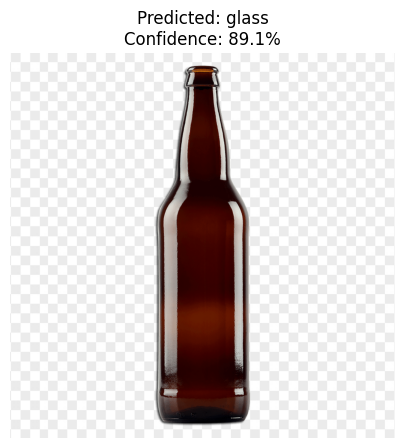


All probabilities:
cardboard: 0.0%
glass: 89.1%
metal: 10.6%
paper: 0.0%
plastic: 0.3%
trash: 0.0%


In [23]:
# Get the name of the uploaded file
uploaded_filename = list(uploaded.keys())[0]
print("Uploaded file:", uploaded_filename)

# Predict function
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)[0]
        confidence, predicted = torch.max(probabilities, 0)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    # Show result
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence_score:.1f}%", fontsize=12)
    plt.axis('off')
    plt.show()

    # Show all class probabilities
    print("\nAll probabilities:")
    for i, prob in enumerate(probabilities):
        print(f"{class_names[i]}: {prob.item()*100:.1f}%")

# Run prediction
predict_image(uploaded_filename)